In [55]:
import pandas as pd

sm = pd.read_csv("../data/processed/germany_social_clean.csv")
ec = pd.read_csv("../data/processed/germany_ecommerce_clean.csv")

# 1 Dataset Overview

This section examines the overall structure of the cleaned datasets before exploratory analysis.

Objectives:

- Verify dataset dimensions
- Inspect available variables
- Review data types
- Examine missing values
- Understand distribution of observations

Datasets:

1. Germany Social Media Dataset (`germany_social_clean.csv`)
2. Germany Ecommerce Dataset (`germany_ecommerce_clean.csv`)

### Observation

This step verifies the number of rows and columns in both datasets.

Purpose:

- Confirm successful export from cleaning stage
- Check consistency between social media and ecommerce datasets
- Identify possible row loss during filtering

In [56]:
print("SOCIAL MEDIA DATASET")
print(sm.shape)

print("\nECOMMERCE DATASET")
print(ec.shape)

SOCIAL MEDIA DATASET
(384, 25)

ECOMMERCE DATASET
(288, 12)


### Dataset Summary

This project uses two Eurostat datasets to analyze digital engagement and ecommerce behavior in Germany.

The Social Media dataset contains indicators related to email usage, product information search, online news reading, and social media participation. These indicators help measure how individuals engage with digital technologies and online activities.

The Ecommerce dataset contains indicators representing different levels of online purchasing frequency, including individuals who made 3–5, 6–10, or more than 10 online purchases during the previous three months.

Together, these datasets provide insight into digital behavior patterns and allow the exploration of how demographic factors such as education, age, and gender relate to digital engagement and ecommerce participation.


### Variable Inspection

This section reviews available variables.

Important analytical variables:

- `year`
- `demo_code`
- `education_level`
- `indicator_name`
- `value`

These variables will be used in later demographic and temporal analysis.

In [57]:
sm_indicator_map = {
    'I_IUEM': 'Email Usage',
    'I_IUIF': 'Product Information Search',
    'I_IUNW1': 'Online News Reading',
    'I_IUSNET': 'Social Media Participation'
}

sm['indicator_name'] = sm['indicator_code'].map(sm_indicator_map)

### Data Types Review

This step checks variable formats.

Expected structure:

- Numeric variables:
    - value
    - year

- Categorical variables:
    - demographic
    - education_level
    - indicator_name

This ensures variables are suitable for aggregation and visualization.

### Missing Value Observation

Most analytical variables contain no missing values.

No missing values were found in:

- value
- year
- education_level
- indicator_name
- demographic

Missing values appear mainly in metadata columns:

- obs_flag
- demo_type
- missing_flag

These fields contain Eurostat annotations and do not affect analysis.

In [63]:
#missing value
sm.isnull().sum().sort_values(
ascending=False
)


Confidentiality status (flag)             384
conf_status                               384
Observation value                         384
Time                                      384
Observation status (Flag) V2 structure    304
obs_flag                                  304
STRUCTURE                                   0
year                                        0
indicator_name                              0
demo_type                                   0
missing_flag                                0
value                                       0
Geopolitical entity (reporting)             0
STRUCTURE_ID                                0
country                                     0
demographic                                 0
demo_code                                   0
Unit of measure                             0
unit                                        0
indicator                                   0
indicator_code                              0
Time frequency                    

In [64]:
ec.isnull().sum().sort_values(
ascending=False
)

obs_flag           243
demo_type          108
missing_flag       108
demo_code            0
demographic          0
education_level      0
indicator_code       0
indicator_name       0
country              0
year                 0
unit                 0
value                0
dtype: int64

### Descriptive Statistics

This section summarizes numerical variables.

Key metrics:

- Mean
- Standard deviation
- Minimum
- Maximum

Focus variable:

`value`

This variable represents percentage indicators reported by Eurostat.

## Section 2 — Temporal Coverage

# 2 Temporal Coverage

Check available years and yearly balance.

In [67]:
sorted(
sm['year'].unique()
)

[np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

In [145]:
sorted(
ec['year'].unique()
)

[np.int64(2020), np.int64(2021), np.int64(2023), np.int64(2025)]

## Section 3 — Education Coverage

# Observation:

The education segment counts are not equal between the social media and e-commerce datasets. This is expected because the datasets contain different indicators and different year availability. Social media has broader temporal and indicator coverage, while e-commerce purchase-frequency indicators are available for fewer years. Therefore, row counts should not be directly compared across datasets.

### Education segments

In [172]:
sm['education_level'].value_counts()

education_level
Not Education Segment    168
High Education            72
Low Education             72
Medium Education          72
Name: count, dtype: int64

In [72]:
ec[
'education_level'
].value_counts()

education_level
Not Education Segment    180
High Education            36
Low Education             36
Medium Education          36
Name: count, dtype: int64

## Section 4 — Indicator Coverage

In [75]:
sm[
'indicator_name'
].value_counts()

indicator_name
Email Usage                   96
Product Information Search    96
Online News Reading           96
Social Media Participation    96
Name: count, dtype: int64

In [76]:
ec[
'indicator_name'
].value_counts()

indicator_name
Moderate Purchase Frequency (3–5 purchases)     96
High Purchase Frequency (6–10 purchases)        96
Very High Purchase Frequency (10+ purchases)    96
Name: count, dtype: int64

### Why Indicator Coverage Matters

The selected indicators represent key dimensions of digital engagement and ecommerce participation. Understanding the available indicators ensures that subsequent analyses focus on meaningful aspects of online behavior rather than isolated measurements.

## Section 5 — Social Media Trend Over Time

# Social Media Trend Analysis

Objective:

Analyze how social media usage changed in Germany from 2020–2025.

This section evaluates yearly trends using average indicator values.

## Which digital activities are most popular?

In [111]:
indicator_avg = (
    sm.groupby('indicator_name')['value']
      .mean()
      .reset_index()
      .sort_values('value', ascending=False)
)

indicator_avg

,indicator_name,value
0,Email Usage,82.490104
2,Product Information Search,66.020625
1,Online News Reading,60.587083
3,Social Media Participation,55.125000


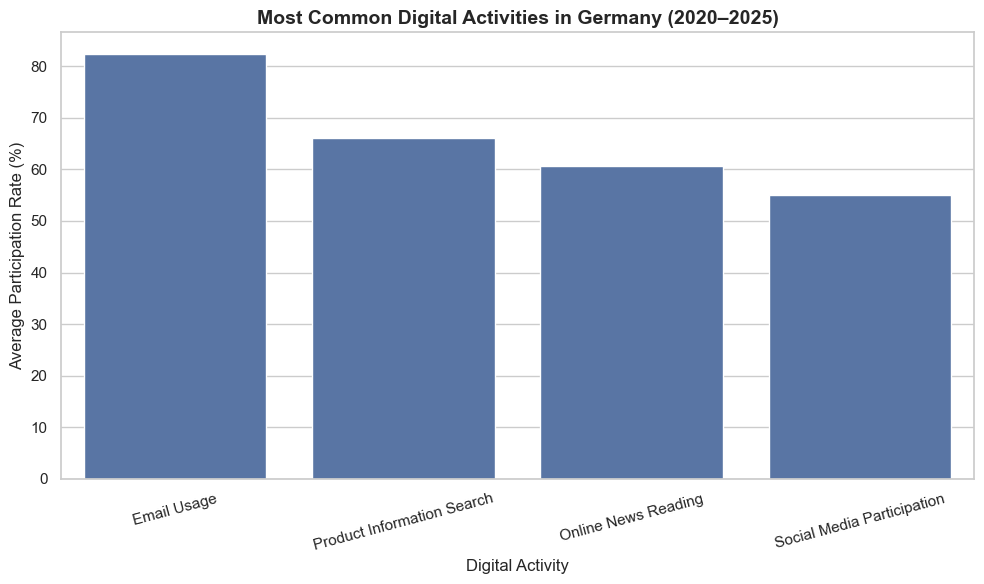

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

indicator_avg = (
    sm.groupby('indicator_name')['value']
      .mean()
      .reset_index()
      .sort_values('value', ascending=False)
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=indicator_avg,
    x='indicator_name',
    y='value'
)

plt.title(
    'Most Common Digital Activities in Germany (2020–2025)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Digital Activity')
plt.ylabel('Average Participation Rate (%)')

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

## Observation

This chart compares the average participation rate of four major digital activities in Germany between 2020 and 2025.

Email usage recorded the highest average participation rate (82.5%), making it the most common digital activity. Product information search ranked second (66.0%), indicating that many individuals use the internet to research products and services before making decisions. Online news reading also remained popular (60.6%), while social media participation showed the lowest average participation rate (55.1%).

## Why This Analysis Matters

Before analyzing trends and demographic differences, it is important to understand which digital activities are most common among internet users. These insights help identify where people spend their time online and which channels may offer the greatest opportunities for communication, information sharing, and digital engagement.

## How has overall digital engagement changed over time?

In [77]:
sm_year = sm.groupby(
'year'
)['value'].mean().reset_index()

sm_year

,year,value
0,2020,75.136094
1,2021,60.888750
2,2022,61.270000
3,2023,57.106563
4,2024,70.291094
5,2025,71.641719


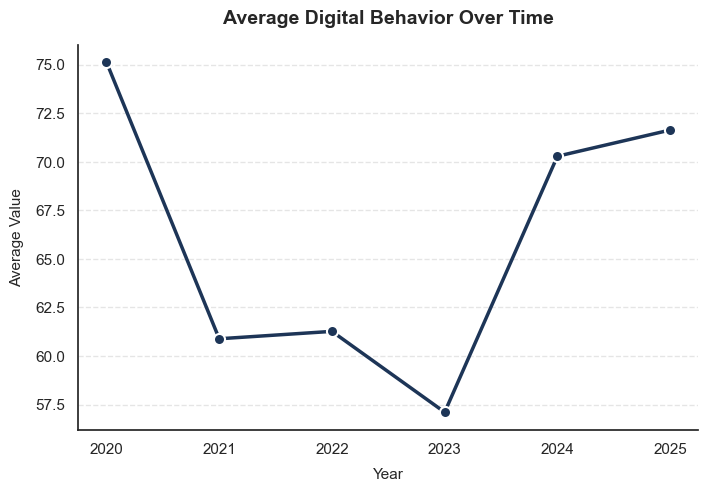

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, minimalist background style (removes the default grey/harsh lines)
sns.set_theme(style="white")

# 2. Initialize the figure size
plt.figure(figsize=(8, 5))

# 3. Plot the line with custom colors, thickness, and larger markers
sns.lineplot(
    data=sm_year,
    x='year',
    y='value',
    marker='o',
    markersize=8,          # Makes the data points more distinct
    linewidth=2.5,         # Thickens the line for better readability
    color='#1d3557',       # Swaps default blue for a sleek navy hex code
    markerfacecolor='#1d3557',
    markeredgecolor='w',   # Gives markers a clean white border
    markeredgewidth=1.5
)

# 4. Add subtle horizontal gridlines to help guide the eye across Y-values
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

# 5. Add styled titles and labels
plt.title('Average Digital Behavior Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, labelpad=8)
plt.ylabel('Average Value', fontsize=11, labelpad=8)

# 6. Crucial step: Remove the top and right black border boxes (spines)
sns.despine()

# 7. Render the final clean visualization
plt.show()

### Observation

This chart shows the average level of digital engagement in Germany across the observed years.

The values represent a combined average of multiple digital behavior indicators, including email usage, internet usage, product information search, online news reading, and social media participation.

Overall digital engagement remains relatively stable over time, although some fluctuations are visible between years.

Because multiple indicators are averaged together, this chart should be interpreted as a broad digital engagement trend rather than a specific activity trend.

## Section 6 — Ecommerce Trend

# Ecommerce Trend Analysis

Objective:

Examine purchase behavior trends across years.

In [79]:
ec_year_indicator = (
    ec.groupby(['year', 'indicator_name'])['value']
      .mean()
      .reset_index()
)

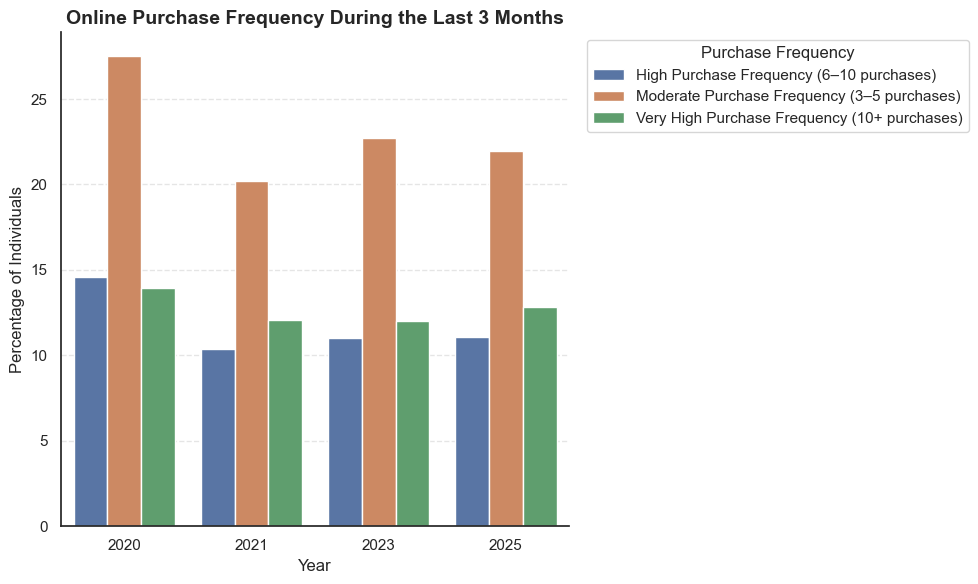

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ec_year_indicator,
    x='year',
    y='value',
    hue='indicator_name'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.title(
    'Online Purchase Frequency During the Last 3 Months',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Percentage of Individuals')

plt.legend(
    title='Purchase Frequency',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

### Observation


Instead of averaging all ecommerce categories together, this visualization displays each purchase-frequency group separately.

This makes it easier to understand how online purchasing behavior is distributed across the population and how those patterns change over time.

The Moderate Purchase Frequency group (3–5 purchases) consistently represents the largest segment of online shoppers across all observed years.

The chart shows the percentage of individuals in Germany who made 3–5, 6–10, or more than 10 online purchases during the previous three months.

These categories are based on the official Eurostat ecommerce frequency indicators and provide insight into the intensity of online shopping behavior over time.

## Section 7 — Education comparison

# Education Level Comparison

Objective:

Compare digital behavior among education groups.

In [126]:
sm_edu_only = sm[
    sm['education_level'].isin([
        'Low Education',
        'Medium Education',
        'High Education'
    ])
]

In [129]:
sm_edu_indicator = (
    sm_edu_only.groupby(['education_level', 'indicator_name'])['value']
      .mean()
      .reset_index()
)

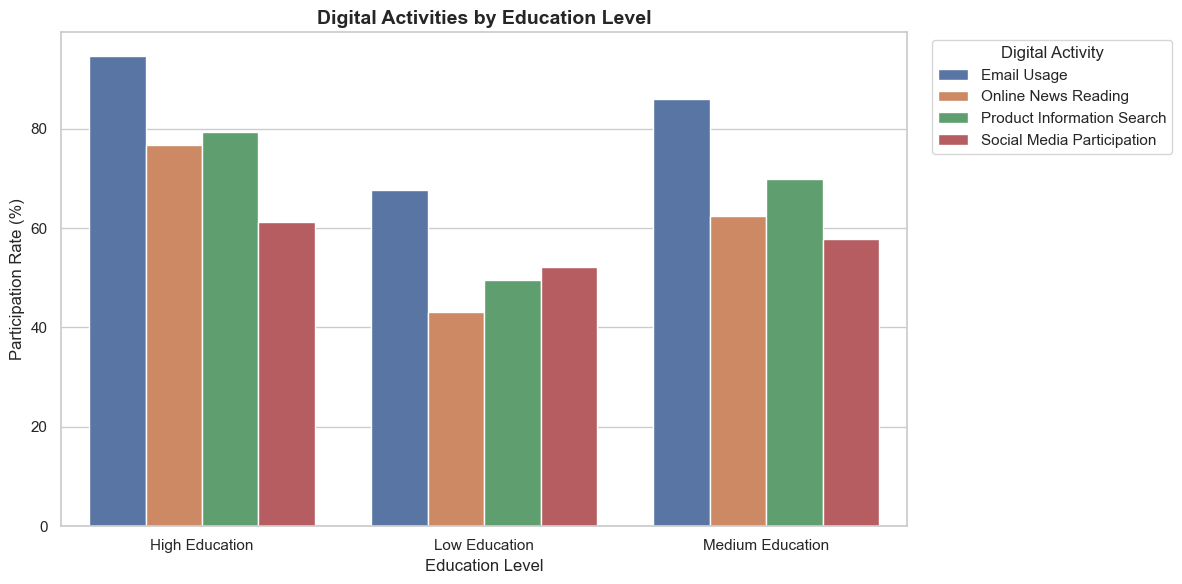

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.barplot(
    data=sm_edu_indicator,
    x='education_level',
    y='value',
    hue='indicator_name'
)

plt.title(
    'Digital Activities by Education Level',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Education Level')
plt.ylabel('Participation Rate (%)')

plt.legend(
    title='Digital Activity',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [131]:
sm_edu = sm_edu_only.groupby(
'education_level'
)['value'].mean().reset_index()

sm_edu

,education_level,value
0,High Education,78.002222
1,Low Education,53.100278
2,Medium Education,69.026944


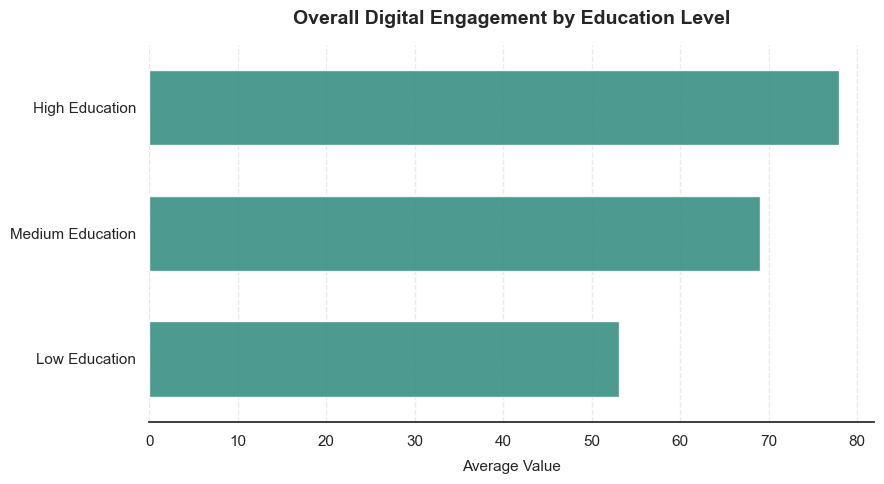

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean minimalist style
sns.set_theme(style="white")
plt.figure(figsize=(9, 5))

# Sort the dataframe by value first so the longest/highest bars sit nicely at the top
df_sorted = sm_edu.sort_values(by='value', ascending=False)

# Create a horizontal bar plot (swap x and y)
sns.barplot(
    data=df_sorted,
    x='value',
    y='education_level',
    color='#2a9d8f',       # Clean, modern teal hex color
    alpha=0.9,
    width=0.6              # Gives breathing room between bars
)

# Soft vertical grid lines to guide the eye across values
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

# Beautiful Typography
plt.title('Overall Digital Engagement by Education Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Value', fontsize=11, labelpad=8)
plt.ylabel('', fontsize=11) # Removing 'education_level' completely since the categories speak for themselves

# Clean up layout and drop outer frames
sns.despine(left=True, bottom=False) # Keep bottom line, remove left spine for a floating look
plt.tight_layout()
plt.show()

### Observation

Digital engagement varies across education groups.

The chart helps identify whether education level is associated with differences in online activity.

Higher values indicate stronger participation in digital activities such as internet usage, email usage, social media participation, and online information search.

In [133]:
ec_edu_only = ec[
    ec['education_level'].isin([
        'Low Education',
        'Medium Education',
        'High Education'
    ])
]

## Do highly educated individuals purchase online more frequently?

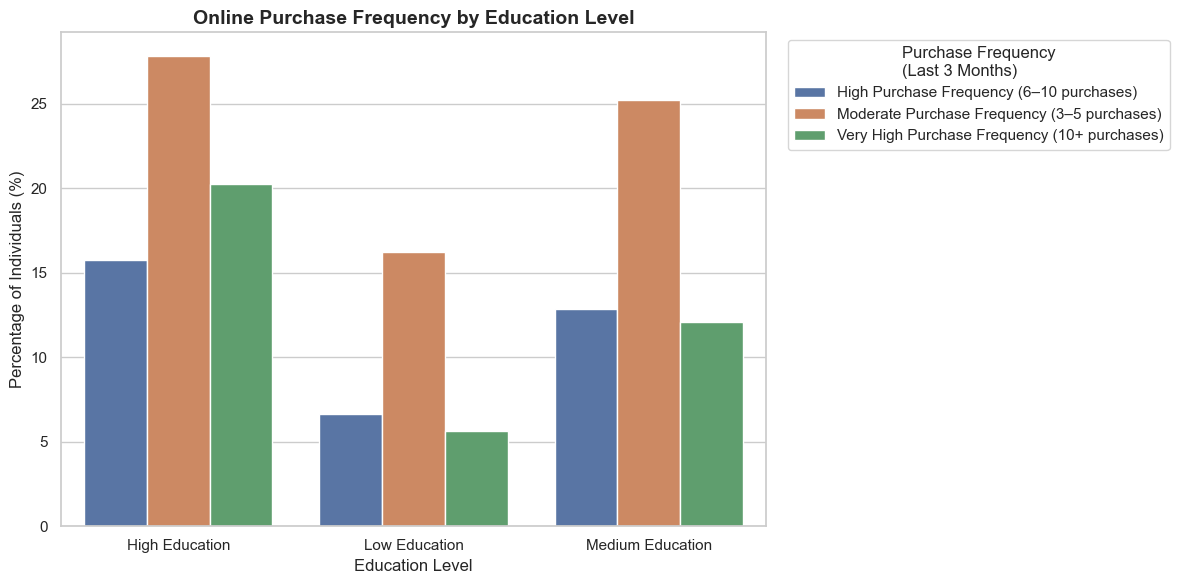

In [141]:
ec_edu_indicator = (
    ec_edu_only
    .groupby(['education_level', 'indicator_name'])['value']
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

sns.barplot(
    data=ec_edu_indicator,
    x='education_level',
    y='value',
    hue='indicator_name'
)

plt.title(
    'Online Purchase Frequency by Education Level',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Education Level')
plt.ylabel('Percentage of Individuals (%)')

plt.legend(
    title='Purchase Frequency\n(Last 3 Months)',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [134]:
ec_year_indicator = (
    ec_edu_only.groupby(
        ['year', 'indicator_name']
    )['value']
    .mean()
    .reset_index()
)

ec_year_indicator.head()

,year,indicator_name,value
0,2020,High Purchase Frequency (6–10 purchases),14.690000
1,2020,Moderate Purchase Frequency (3–5 purchases),27.618889
2,2020,Very High Purchase Frequency (10+ purchases),13.921111
3,2021,High Purchase Frequency (6–10 purchases),10.417778
4,2021,Moderate Purchase Frequency (3–5 purchases),20.148889


In [135]:
ec_edu = (
    ec_edu_only.groupby('education_level')['value']
      .mean()
      .reset_index()
      .sort_values('value', ascending=False)
)

ec_edu

,education_level,value
0,High Education,21.296111
2,Medium Education,16.735556
1,Low Education,9.494722


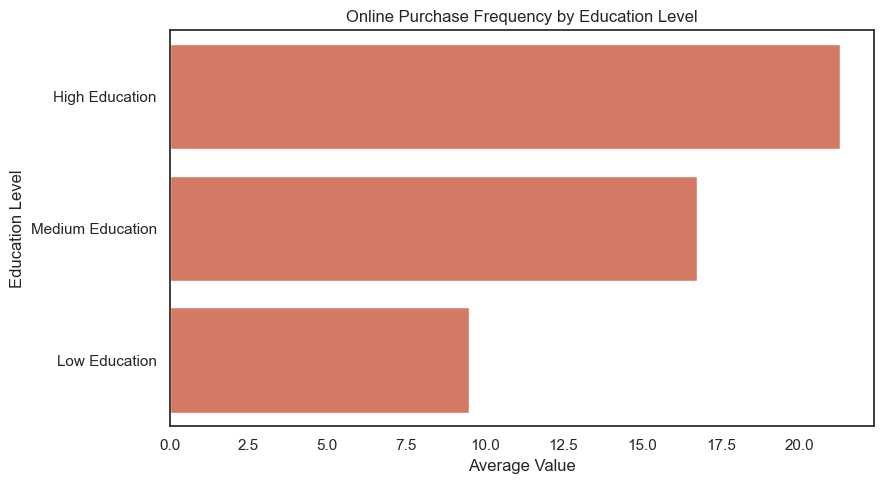

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(9,5))

sns.barplot(
    data=ec_edu,
    x='value',
    y='education_level',
    color='#e76f51'
)

plt.title('Online Purchase Frequency by Education Level')
plt.xlabel('Average Value')
plt.ylabel('Education Level')

plt.tight_layout()
plt.show()

# Observation

This chart shows average ecommerce activity across education levels in Germany.

Individuals with higher education levels recorded the highest ecommerce participation, while those with lower education levels showed substantially lower engagement. Medium education groups fell between these two extremes.

The results suggest that education level may be associated with online purchasing behavior, with more highly educated individuals participating more actively in ecommerce activities.

# Why This Analysis Is Important

Understanding ecommerce behavior by education level helps identify which population segments are most engaged in online purchasing. These insights can support targeted digital marketing strategies, customer segmentation, and business decision-making.

### Education Analysis Summary

Higher education groups generally reported stronger participation in both digital activities and ecommerce behavior. These findings suggest that education may be an important demographic factor associated with digital engagement and online purchasing patterns.

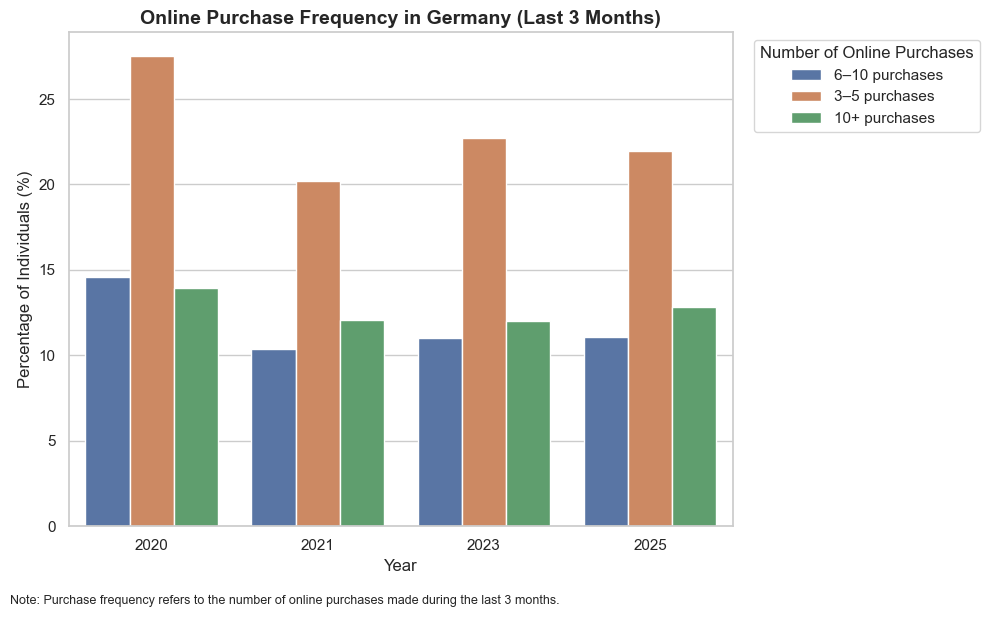

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create yearly ecommerce frequency data
ec_year_indicator = (
    ec.groupby(['year', 'indicator_name'])['value']
      .mean()
      .reset_index()
)

# Shorter labels for clearer legend
label_map = {
    'Moderate Purchase Frequency (3–5 purchases)': '3–5 purchases',
    'High Purchase Frequency (6–10 purchases)': '6–10 purchases',
    'Very High Purchase Frequency (10+ purchases)': '10+ purchases'
}

ec_year_indicator['purchase_group'] = ec_year_indicator['indicator_name'].map(label_map)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ec_year_indicator,
    x='year',
    y='value',
    hue='purchase_group'
)

plt.title(
    'Online Purchase Frequency in Germany (Last 3 Months)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Percentage of Individuals (%)')

plt.legend(
    title='Number of Online Purchases',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.figtext(
    0.01,
    -0.02,
    'Note: Purchase frequency refers to the number of online purchases made during the last 3 months.',
    ha='left',
    fontsize=9
)

plt.tight_layout()
plt.show()

### Observation

This chart compares online purchasing activity across education levels.

Differences between groups may indicate that education level influences ecommerce participation.

Groups with higher values report more frequent online purchasing behavior.

## Section 8 — Indicator comparison

### Purpose

This analysis compares the average participation rates across individual digital activities and ecommerce categories. The goal is to identify which activities are most common among German internet users.

In [85]:
sm_indicator = sm.groupby(
'indicator_name'
)['value'].mean().reset_index()

sm_indicator

,indicator_name,value
0,Email Usage,82.490104
1,Online News Reading,60.587083
2,Product Information Search,66.020625
3,Social Media Participation,55.125000


In [86]:
sm_year_indicator = sm.groupby(
    ['year','indicator_name']
)['value'].mean().reset_index()

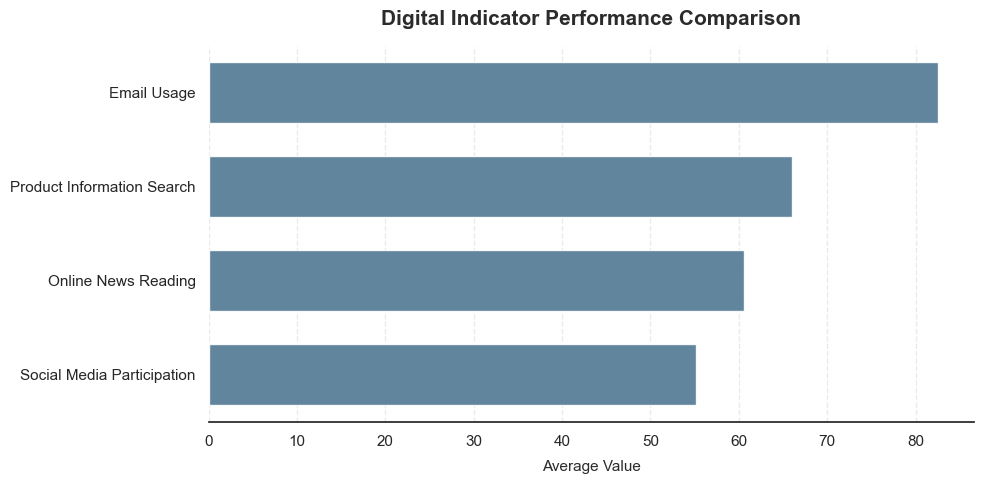

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply a minimalist white theme
sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

# 2. CRITICAL: Sort the data descending by value so the bars cascade beautifully
df_sorted = sm_indicator.sort_values(by='value', ascending=False)

# 3. Create a horizontal bar chart by swapping x and y
sns.barplot(
    data=df_sorted,
    x='value',
    y='indicator_name',
    color='#457b9d',       # Clean, modern slate blue hex
    alpha=0.9,
    width=0.65             # Add slight spacing between bars
)

# 4. Add subtle background vertical grids to guide value reading
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

# 5. Clean, descriptive titles and labels
plt.title('Digital Indicator Performance Comparison', fontsize=15, fontweight='bold', pad=15, color='#2b2b2b')
plt.xlabel('Average Value', fontsize=11, labelpad=8, color='#2b2b2b')
plt.ylabel('')  # Drop the redundant 'indicator_name' label entirely to save space

# 6. Keep the baseline but drop the top, right, and left frames for a floating effect
sns.despine(left=True, bottom=False)

# Ensure the long text labels fit nicely on the left edge without clipping
plt.tight_layout()
plt.show()

### Observation

Email Usage shows the highest average participation among the digital behavior indicators.

Internet Usage, Product Information Search, Online News Reading, and Social Media Participation show lower average values.

Product Information Search is particularly important from a digital marketing perspective because it reflects consumers using online channels to research products before making purchasing decisions.

In [93]:
ec_indicator = ec.groupby(
'indicator_name'
)['value'].mean().reset_index()

ec_indicator

,indicator_name,value
0,High Purchase Frequency (6–10 purchases),11.776354
1,Moderate Purchase Frequency (3–5 purchases),23.105000
2,Very High Purchase Frequency (10+ purchases),12.720521


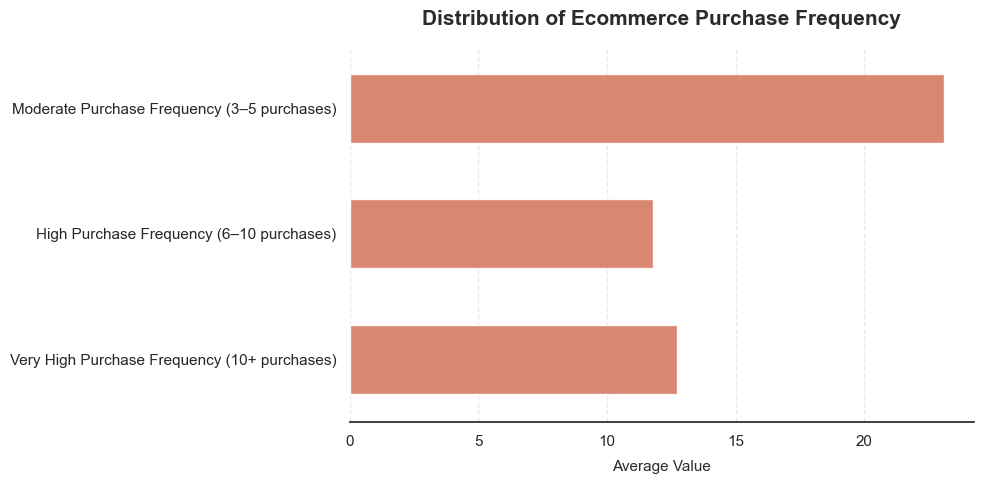

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean background style
sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

# 2. CRITICAL: Manually force the logical, sequential order of intensity
logical_order = [
    'Moderate Purchase Frequency (3–5 purchases)',
    'High Purchase Frequency (6–10 purchases)',
    'Very High Purchase Frequency (10+ purchases)'
]

# 3. Create a horizontal bar chart
sns.barplot(
    data=ec_indicator,
    x='value',
    y='indicator_name',
    order=logical_order,   # Enforces the natural sequential order
    color='#e76f51',       # Warm coral hex code
    alpha=0.9,
    width=0.55             # Adds balanced breathing room between bars
)

# 4. Subtle scale gridlines
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

# 5. Clean, professional text hierarchy
plt.title('Distribution of Ecommerce Purchase Frequency', fontsize=15, fontweight='bold', pad=15, color='#2b2b2b')
plt.xlabel('Average Value', fontsize=11, labelpad=8, color='#2b2b2b')
plt.ylabel('')  # Drop the redundant 'indicator_name' label entirely

# 6. Remove harsh borders
sns.despine(left=True, bottom=False)

# Auto-adjust so your long category labels don't get cut off on the left margin
plt.tight_layout()
plt.show()

### Observation

The Moderate Purchase Frequency category (3–5 purchases) represents the largest group of online shoppers.

The High Purchase Frequency (6–10 purchases) and Very High Purchase Frequency (10+ purchases) groups account for smaller shares of the population.

This indicates that moderate ecommerce participation is more common than intensive online purchasing behavior.

## Section 9 — Distribution

## Distribution of Digital Activity and Ecommerce Values

This section explores how participation values are distributed across the datasets. The purpose is to identify common participation levels and detect potential concentration or variation in the observed indicators.

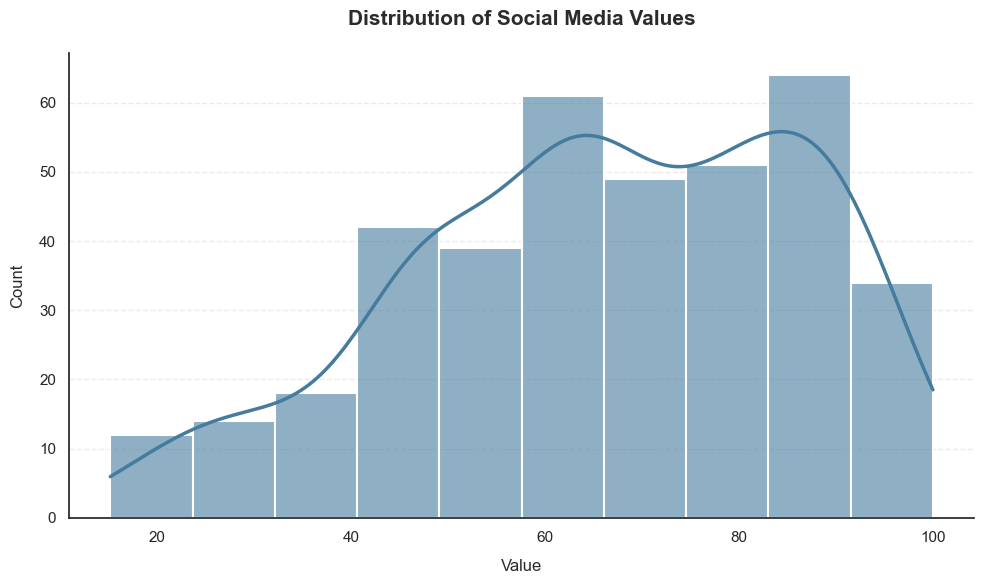

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean theme
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 2. Plot the histogram with a smooth KDE curve overlay
sns.histplot(
    data=sm,  # Social media dataframe
    x='value',
    kde=True,               # Adds the beautiful smooth distribution line
    color='#457b9d',        # Clean slate blue color
    alpha=0.6,              # Soft transparency for the bars
    edgecolor='w',          # Crisp white edges instead of heavy black lines
    linewidth=1.5,
    line_kws={'linewidth': 2.5, 'color': '#1d3557'} # Custom styles for the trendline
)

# 3. Add faint horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#cccccc')

# 4. Premium Typography & Labels
plt.title('Distribution of Social Media Values', fontsize=15, fontweight='bold', pad=20, color='#2b2b2b')
plt.xlabel('Value', fontsize=12, labelpad=10, color='#2b2b2b')
plt.ylabel('Count', fontsize=12, labelpad=10, color='#2b2b2b')

# 5. Clean layout frames
sns.despine()

plt.tight_layout()
plt.show()

### Observation

This histogram shows how digital engagement values are distributed across observations.

Most values appear concentrated within a specific range, suggesting relatively consistent digital behavior across the population.

The distribution also helps identify potential outliers and unusually high or low observations.

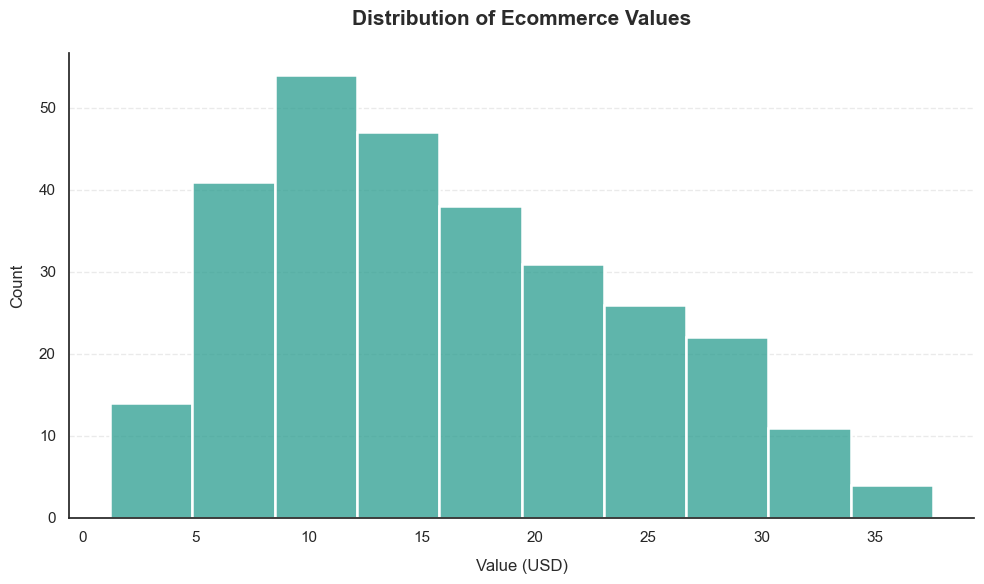

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize a clean, presentation-ready theme
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 2. Plot the histogram with soft borders and light transparency
sns.histplot(
    data=ec,          # Ecommerce dataframe
    x='value',
    color='#2a9d8f',    # A vibrant, premium teal-green palette color
    alpha=0.75,         # Softens the fill color slightly
    edgecolor='w',      # Crisp white edges create elegant negative space gaps
    linewidth=1.8       # Clean separation thickness
)

# 3. Add soft, faint horizontal reference lines
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#cccccc')

# 4. Premium Typography and Labels
plt.title('Distribution of Ecommerce Values', fontsize=15, fontweight='bold', pad=20, color='#2b2b2b')
plt.xlabel('Value (USD)', fontsize=12, labelpad=10, color='#2b2b2b')
plt.ylabel('Count', fontsize=12, labelpad=10, color='#2b2b2b')

# 5. Remove the heavy top and right border boxes
sns.despine()

# Ensure layout fits beautifully without margins clipping labels
plt.tight_layout()
plt.show()

### Observation

This histogram displays the distribution of ecommerce participation values.

Most observations fall within lower to moderate ranges, while higher purchase-frequency values are less common.

This supports previous findings that moderate online purchasing behavior is more widespread than very high purchasing frequency.

In [97]:
sm[['indicator_code','indicator_name']].drop_duplicates()

,indicator_code,indicator_name
0,I_IUEM,Email Usage
96,I_IUIF,Product Information Search
192,I_IUNW1,Online News Reading
288,I_IUSNET,Social Media Participation


In [98]:
ec[['indicator_code','indicator_name']].drop_duplicates()

,indicator_code,indicator_name
0,I_BF_3-5,Moderate Purchase Frequency (3–5 purchases)
4,I_BF_6-10,High Purchase Frequency (6–10 purchases)
8,I_BF_GT10,Very High Purchase Frequency (10+ purchases)


### Section 10 — Year × Indicator Analysis
Objective

Instead of averaging everything together, now I analyze each behavior separately over time.

For example:

Did Email Usage increase or decrease?
Did Product Information Search increase?
Did Social Media Participation grow?
Did Online News Reading change?

This gives much more business insight than overall averages.

In [101]:
sm_year_indicator = (
    sm.groupby(['year', 'indicator_name'])['value']
      .mean()
      .reset_index()
)

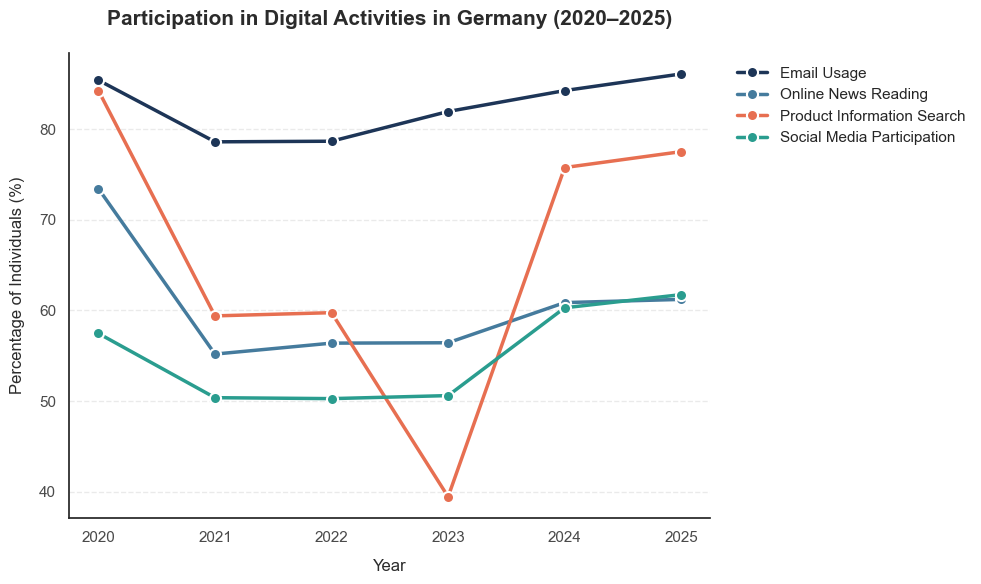

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional white canvas style
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 2. Define a sophisticated, distinct color palette for the 4 indicators
# Using clean, intentional colors instead of the generic default hues
custom_palette = ["#1d3557", "#457b9d", "#e76f51", "#2a9d8f"]

# 3. Plot the trends
sns.lineplot(
    data=sm_year_indicator,
    x='year',
    y='value',
    hue='indicator_name',
    palette=custom_palette,
    marker='o',
    markersize=8,           # Punchy, distinct data points
    linewidth=2.5,          # Thicker lines for emphasis
    markeredgecolor='w',    # White outer ring borders to make points pop
    markeredgewidth=1.5
)

# 4. Refine the gridlines (keep only the horizontal ones to reduce noise)
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#cccccc')

# 5. Elevate Typography and Labels
plt.title('Participation in Digital Activities in Germany (2020–2025)', fontsize=15, fontweight='bold', pad=20, color='#2b2b2b')
plt.xlabel('Year', fontsize=12, labelpad=10, color='#2b2b2b')
plt.ylabel('Percentage of Individuals (%)', fontsize=12, labelpad=10, color='#2b2b2b')

# 6. Ensure the X-axis handles years as neat integers instead of float decimals
# Assuming your years run from 2020 onwards based on your dataframe head
unique_years = sorted(sm_year_indicator['year'].unique())
plt.xticks(unique_years, fontsize=11, color='#4a4a4a')
plt.yticks(fontsize=11, color='#4a4a4a')

# 7. Move the legend outside the plot so it stops blocking your lines
plt.legend(
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=False,          # Removes the clunky box border
    fontsize=11,
    title=None              # Suppresses the raw variable name 'indicator_name' header
)

# 8. De-clutter framework borders (top and right)
sns.despine()

# Tight layout ensures the newly positioned legend fits perfectly in the output window
plt.tight_layout()
plt.show()

### Observation

This chart compares four major digital activities in Germany between 2020 and 2025: email usage, online news reading, product information search, and social media participation.

Email usage remained the most common digital activity throughout the period, consistently recording the highest participation rates. Product information search experienced the largest fluctuations, declining between 2020 and 2023 before recovering strongly in later years. Online news reading remained relatively stable with moderate participation levels, while social media participation showed gradual growth after 2023.


# what this chart is important?
The chart is important because it provides a high-level view of how Germans engage with different online activities over time. Understanding these behavioral patterns helps identify which digital activities are most prevalent and how they evolve across years.

This analysis also supports the broader objective of the project, which is to explore the relationship between digital behavior and e-commerce activity in Germany. By examining trends in communication, information seeking, and social networking, we can identify whether changes in online behavior correspond with changes in online purchasing patterns. These insights may help reveal which digital activities are most closely associated with consumer engagement and potential e-commerce participation.

# short reason
I'm using this chart to understand how digital behavior changes over time before investigating whether those changes are related to e-commerce activity.

### Relationship Between Digital Behavior and Ecommerce

Now moving from descriptive analysis ("what is happening?") to relationship analysis ("are things connected?").

# Step 1 — Create a clean merged dataset

In [104]:
ec_year = (
    ec.groupby('year')['value']
      .mean()
      .reset_index()
)

ec_year

,year,value
0,2020,18.691667
1,2021,14.215833
2,2023,15.273194
3,2025,15.288472


In [105]:
merged = sm_year.merge(
    ec_year,
    on='year',
    suffixes=('_social', '_ecommerce')
)

merged

,year,value_social,value_ecommerce
0,2020,75.136094,18.691667
1,2021,60.888750,14.215833
2,2023,57.106563,15.273194
3,2025,71.641719,15.288472


# Step 2 — Make correlation matrix

# When digital activity increases, does ecommerce activity also increase?

In [106]:
merged[['value_social', 'value_ecommerce']].corr()

,value_social,value_ecommerce
value_social,1.000000,0.723739
value_ecommerce,0.723739,1.000000


# Relationship Between Digital Activity and Ecommerce Activity

Purpose:
This analysis examines whether higher levels of digital engagement are associated with higher ecommerce activity in Germany over time.

Observation:
The correlation coefficient between average digital activity and average ecommerce activity was 0.724, indicating a strong positive relationship. Years with higher participation in online activities generally showed higher levels of ecommerce engagement. However, the analysis is based on only four available years of data, so the results should be interpreted as an exploratory finding rather than definitive evidence of causation.

# in simple words
A positive relationship was observed between digital activity and ecommerce activity. However, the analysis is based on a limited number of years and does not establish a cause-and-effect relationship.

### SECTION 10 --- Age Analysis

## Social Media

In [162]:
age_codes = ['Y16_24', 'Y25_64', 'Y65_74']

age_map = {
    'Y16_24': '16–24',
    'Y25_64': '25–64',
    'Y65_74': '65–74'
}

sm_age = sm[sm['demo_code'].isin(age_codes)].copy()
sm_age['age_group'] = sm_age['demo_code'].map(age_map)

sm_age_summary = (
    sm_age
    .groupby('age_group')['value']
    .mean()
    .reset_index()
)

sm_age_summary

,age_group,value
0,16–24,73.943750
1,25–64,69.707500
2,65–74,46.205417


In [161]:
ec_age_codes = ['Y16_24', 'Y25_54', 'Y55_74']

ec_age_map = {
    'Y16_24': '16–24',
    'Y25_54': '25–54',
    'Y55_74': '55–74'
}

ec_age = ec[ec['demo_code'].isin(ec_age_codes)].copy()
ec_age['age_group'] = ec_age['demo_code'].map(ec_age_map)

In [165]:
ec_age_summary = (
    ec_age
    .groupby('age_group')['value']
    .mean()
    .reset_index()
)

ec_age_summary

,age_group,value
0,16–24,16.371667
1,25–54,19.349167
2,55–74,11.397500


Although younger individuals (16–24) exhibit the highest levels of digital activity, the 25–54 age group demonstrates the highest participation in ecommerce activities. This suggests that digital engagement alone does not necessarily translate into greater online purchasing. Economic factors such as income and purchasing power may also influence ecommerce behavior.

# Which age groups are most digitally active?

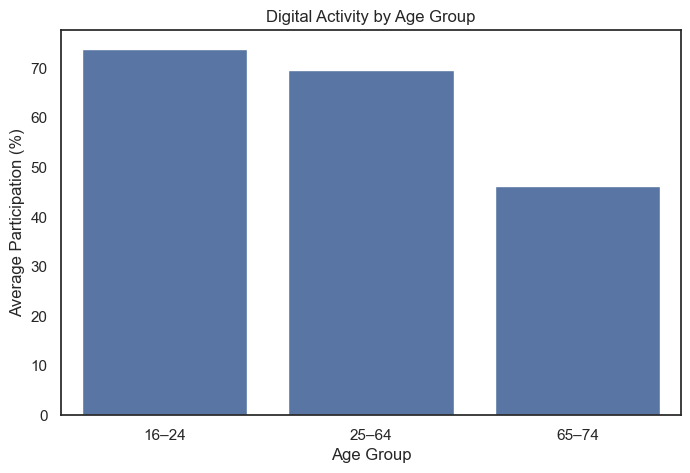

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=sm_age_summary,
    x='age_group',
    y='value'
)

plt.title('Digital Activity by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Participation (%)')

plt.show()

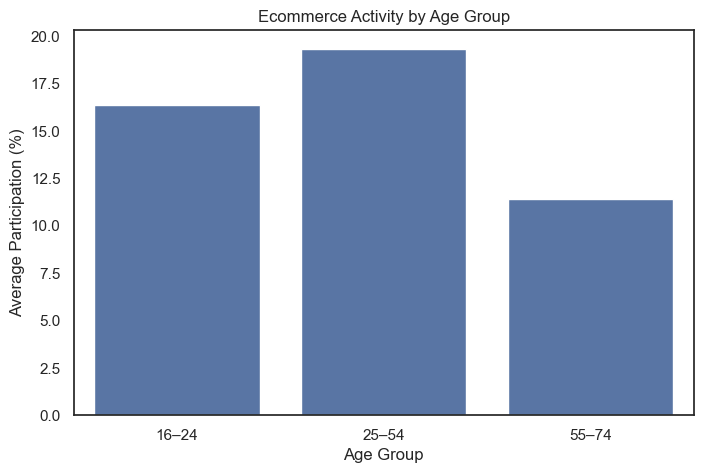

In [167]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=ec_age_summary,
    x='age_group',
    y='value'
)

plt.title('Ecommerce Activity by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Participation (%)')

plt.show()

### Age Analysis Summary

Age appears to play an important role in both digital engagement and ecommerce behavior. Individuals aged 16–24 showed the highest levels of digital activity, while the 25–54 age group demonstrated the highest ecommerce participation. The oldest age group recorded the lowest participation levels in both areas.

### Gender Analysis

In [168]:
gender_codes = ['F_Y16_74', 'M_Y16_74']

gender_map = {
    'F_Y16_74': 'Female',
    'M_Y16_74': 'Male'
}

sm_gender = sm[
    sm['demo_code'].isin(gender_codes)
].copy()

sm_gender['gender'] = sm_gender['demo_code'].map(gender_map)

In [170]:
sm_gender_summary = (
    sm_gender
    .groupby('gender')['value']
    .mean()
    .reset_index()
)

sm_gender_summary

,gender,value
0,Female,65.766250
1,Male,67.796667


In [169]:
ec_gender = ec[
    ec['demo_code'].isin(gender_codes)
].copy()

ec_gender['gender'] = ec_gender['demo_code'].map(gender_map)

In [171]:
ec_gender_summary = (
    ec_gender
    .groupby('gender')['value']
    .mean()
    .reset_index()
)

ec_gender_summary

,gender,value
0,Female,16.202500
1,Male,16.155833


### Gender Analysis Summary

Gender differences in digital activity and ecommerce participation appear to be relatively small. Males reported slightly higher levels of digital engagement than females, but the difference was minimal. Ecommerce participation was nearly identical between males and females. These findings suggest that age and education may have a stronger influence on digital behavior and online purchasing patterns than gender.

# Final Findings & Insights

### Finding 1: Email Remains the Most Common Digital Activity

Email usage consistently recorded the highest participation rates across all years, indicating that it remains an essential communication channel in Germany.

### Finding 2: Product Information Search Shows the Largest Changes

Among the digital activities examined, product information search displayed the greatest fluctuation over time, suggesting that information-seeking behavior is more sensitive to changing conditions than other online activities.

### Finding 3: Moderate Online Purchasing is the Most Common Ecommerce Behavior

The largest share of individuals belonged to the group making between three and five online purchases during the previous three months, indicating that moderate online shopping is more common than high-frequency purchasing.

### Finding 4: Digital Activity and Ecommerce Participation are Positively Related

The correlation analysis revealed a positive relationship between digital activity and ecommerce participation, suggesting that more digitally engaged populations tend to participate more actively in online purchasing.

### Finding 5: Education and Age Matter More Than Gender

Education and age groups showed clearer differences in digital engagement and ecommerce activity than gender. Higher education groups demonstrated stronger participation levels, while younger individuals were the most digitally active. In ecommerce behavior, the 25–54 age group showed the highest participation.


# Recommendations

### Recommendation 1

Continue using email as a core communication and marketing channel because it consistently records the highest participation levels.

### Recommendation 2

Target the 25–54 age group for ecommerce campaigns, as this segment demonstrates the highest levels of online purchasing activity.

### Recommendation 3

Use digital and social platforms to engage younger audiences, as individuals aged 16–24 exhibit the highest levels of digital engagement.

### Recommendation 4

Consider educational differences when designing digital products, services, and marketing campaigns, as higher education groups show stronger participation in digital activities and ecommerce.

### Recommendation 5

Combine digital engagement strategies with ecommerce initiatives, as higher levels of digital activity are associated with higher ecommerce participation.


# Conclusion

This project analyzed digital activity and ecommerce behavior in Germany using Eurostat data. The analysis showed that email remains the most widely used digital activity, while moderate online purchasing represents the most common ecommerce behavior. A positive relationship was observed between digital engagement and ecommerce participation, although this should not be interpreted as evidence of causation. Demographic analysis indicated that education and age play a more significant role in explaining digital behavior than gender. Overall, the findings provide valuable insights into how different population groups engage with digital technologies and online purchasing activities in Germany.
